## Import Libraries

In [1]:
import matplotlib.pylab as pl
import pandas as pd
import pickle
import seaborn as sns
import numpy as np
import catboost as cb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, mean_absolute_percentage_error
import optuna
from sklearn.model_selection import KFold
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_optimization_history
import shap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

## Import dataset

In [2]:
#Raw df without manipulation, required for the Optuna
raw_df = pd.read_csv('(...)/PDRA_Processed_Data_OS.csv') #change this path for the path of the desired dataset
#Make df: the dataset that will be used for the model
df = raw_df.copy()
#drop irrelevant driver performance features. Change this according to the desired analysis.
df = df.drop(['crash', 'minTTC', 'totalGlanceTimeOther', 'TTC'], axis = 1)

df


,subNumber,Gender,driverTraining,eventNumber,Age,drivingExperience,reactionTime,AVR,attenD,euclideanGazeDispersion,gazeEntropy,yawGazeDispersion,pitchGazeDispersion,totalGlanceTimeDriverMirror,totalGlanceTimeInstrumentCluster,totalGlanceTimeOffRoad,totalGlanceTimeOnRoad,totalGlanceTimePassengerMirror,totalGlanceTimeRearMirror
0,3,1,0,0,37,12,2.75,1.24,0.00,0.13,0.50,0.22,0.19,0.000000,0.000000,0.000000,6.499910,0.0,0.0
1,4,1,0,0,27,9,2.57,2.19,3.00,0.01,2.60,0.12,0.09,0.000000,0.000000,3.000092,3.499991,0.0,0.0
2,4,1,0,1,27,9,1.90,2.19,0.00,0.01,2.15,0.14,0.06,0.000000,0.000000,2.976755,3.520544,0.0,0.0
3,4,1,0,2,27,9,2.63,2.19,0.00,0.03,1.86,0.22,0.15,0.000000,0.000000,3.587340,2.757942,0.0,0.0
4,4,1,0,3,27,9,2.00,2.19,0.00,0.04,1.06,0.29,0.15,0.000000,0.000000,5.784356,0.715487,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,32,1,1,3,25,8,1.62,4.66,2.26,0.06,2.15,0.17,0.19,0.000000,1.846824,3.043648,1.608153,0.0,0.0
101,33,0,1,0,39,18,0.38,1.33,0.00,0.07,2.40,0.22,0.15,0.567236,0.106263,0.000000,5.368379,0.0,0.0
102,33,0,1,1,39,18,1.20,1.33,2.35,0.01,2.53,0.10,0.06,0.000000,0.000000,2.955344,3.544664,0.0,0.0
103,33,0,1,2,39,18,1.13,1.33,0.00,0.14,1.46,0.36,0.22,0.695735,0.000000,5.174656,0.628127,0.0,0.0


In [3]:
#Assign the features that will be used in the model
feature_cols = df.columns[1:].to_list()
target_col = 'reactionTime'
feature_cols.remove ('reactionTime')

In [4]:
dict_keys = df.columns
# Define categorical and continuous columns
cat_names = [col for col in dict_keys 
             if df[col].dtype.name == 'category' or df[col].dtype == 'object']
cont_names = [col for col in dict_keys 
             if col not in cat_names and col != 'reactionTime']
#move categorical values to cat_names
#for example, eventNumber and TTC
cols_to_move = [
 'eventNumber',
 #'TTC',
 'driverTraining',
 'Gender',
    
]
cat_names.extend(cols_to_move)
cont_names = [col for col in cont_names if col not in cols_to_move]

#Z-transformation Scaling for the features of the model
class ScalingHandler:
    #in case standardization is not wanted, change the next scaling_method to 'MinMax'
    def __init__(self, scaling_method):
        self.scaling_method = scaling_method
        self.scaler = StandardScaler() if scaling_method == 'standard' else MinMaxScaler()

    def scale_data(self, train_data, test_data, cont_names):
        train_scaled = train_data.copy()
        test_scaled = test_data.copy()

        # Fit scaler on training data and transform both sets
        train_scaled[cont_names] = self.scaler.fit_transform(train_data[cont_names])
        test_scaled[cont_names] = self.scaler.transform(test_data[cont_names])

        return train_scaled, test_scaled

## Optuna function

In [5]:
def objective(trial):
    #in case standardization is not wanted, change the next scaling_method to 'MinMax'
    scaler = ScalingHandler(scaling_method='standard')
    params = {
            # Core Parameters
            'iterations': trial.suggest_int('iterations', 3, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
            'depth': trial.suggest_int('depth', 1, 12),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'random_strength': trial.suggest_float('random_strength', 1e-8, 1.0, log=True),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 20),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0)
        }

    #Here is where we define the number of splits for cross validation. It can be adjusted as see fit.
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(df[feature_cols])):
        train_fold = df.iloc[train_idx]
        valid_fold = df.iloc[valid_idx]
        train_scaled, val_scaled = scaler.scale_data(train_fold, valid_fold, cont_names)

        model = cb.CatBoostRegressor(**params)
        model.fit(
            train_scaled[feature_cols],
            train_fold[target_col],
            cat_features=cat_names,
            eval_set=[(val_scaled[feature_cols], valid_fold[target_col])],
            verbose=False
        )

        pred = model.predict(val_scaled[feature_cols])
        rmse = np.sqrt(mean_squared_error(valid_fold[target_col], pred))
        cv_scores.append(rmse)

    return np.mean(cv_scores)

## Optimize hyperparameters

In [6]:
# Create study with pruner
study = optuna.create_study(
    direction='minimize',  # We want to minimize RMSE
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=50,
        interval_steps=20
    )
)

# Run optimization
#The n_trials can be adjusted as see fit. The original study used 5000.
study.optimize(objective, n_trials=5000, n_jobs=-1)  # n_jobs=-1 uses all cores

# Print results
print("Best trial:")
print("  RMSE: ", study.best_trial.value)
print("  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2025-07-02 12:59:58,977] A new study created in memory with name: no-name-7b9663ba-2286-4876-8e3e-f451169d7676
[I 2025-07-02 13:00:00,930] Trial 6 finished with value: 0.4983531897882886 and parameters: {'iterations': 32, 'learning_rate': 0.011023429709505945, 'depth': 1, 'l2_leaf_reg': 0.05502540143717292, 'bagging_temperature': 0.8039348122212081, 'random_strength': 0.2582566676712805, 'min_data_in_leaf': 11, 'subsample': 0.9443635550719328}. Best is trial 6 with value: 0.4983531897882886.
[I 2025-07-02 13:00:02,463] Trial 0 finished with value: 0.4538532028379899 and parameters: {'iterations': 68, 'learning_rate': 0.07693084433663498, 'depth': 1, 'l2_leaf_reg': 1.3862843312088925e-08, 'bagging_temperature': 0.14597504718925547, 'random_strength': 4.746838275182382e-07, 'min_data_in_leaf': 17, 'subsample': 0.5923731200566948}. Best is trial 0 with value: 0.4538532028379899.
[I 2025-07-02 13:00:03,020] Trial 14 finished with value: 0.4828983223927959 and parameters: {'iterations': 

Best trial:
  RMSE:  0.39373427132399624
  Params: 
    iterations: 457
    learning_rate: 0.1926625641544985
    depth: 1
    l2_leaf_reg: 0.00014134974763275045
    bagging_temperature: 0.8342649969698557
    random_strength: 0.0003937550473881699
    min_data_in_leaf: 1
    subsample: 0.7118623596814421


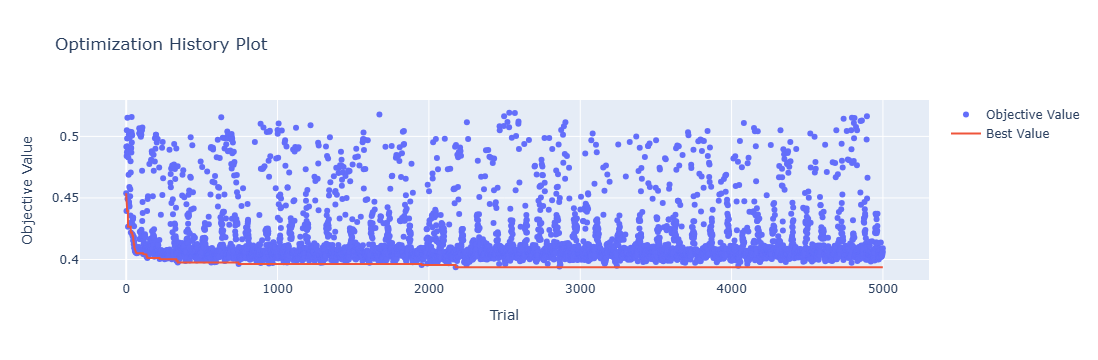

In [7]:
# Plot optimisation history
plot_optimization_history(study)

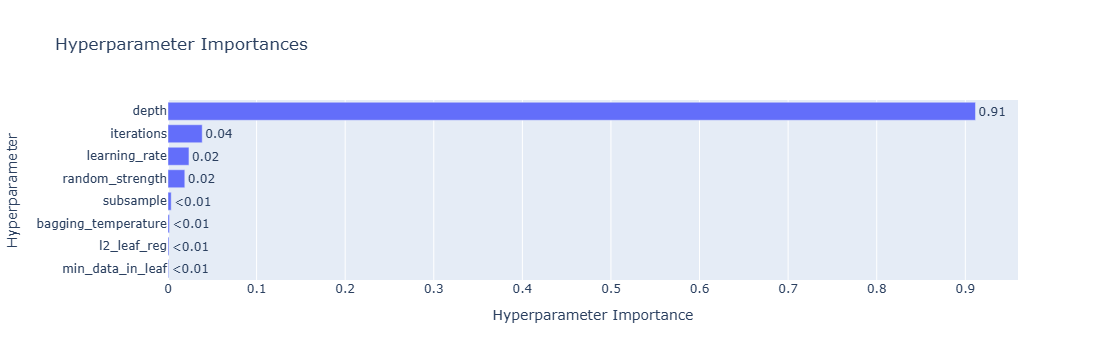

In [8]:
# Plot parameter importances
plot_param_importances(study)

In [9]:
# Print results
print("Best trial:")
print("  RMSE: ", study.best_trial.value)
print("  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")


Best trial:
  RMSE:  0.39373427132399624
  Params: 
    iterations: 457
    learning_rate: 0.1926625641544985
    depth: 1
    l2_leaf_reg: 0.00014134974763275045
    bagging_temperature: 0.8342649969698557
    random_strength: 0.0003937550473881699
    min_data_in_leaf: 1
    subsample: 0.7118623596814421


## Fit the model to data

In [10]:
scaler = ScalingHandler(scaling_method='standard')
# Final evaluation with CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)
catb_predictions = []
actual_values = []
metrics_per_fold = []
shap_values_per_fold = []
fold_models = []  # Store models if needed later
perm_importance_results = [] # List to store permutation importance results

for fold, (train_idx, test_idx) in enumerate(cv.split(df[feature_cols])):
    train_fold = df.iloc[train_idx]
    test_fold = df.iloc[test_idx]

    train_scaled, test_scaled = scaler.scale_data(train_fold, test_fold, cont_names)
    #  CatBoost
    best_cat = cb.CatBoostRegressor(**study.best_trial.params, random_state=11)
    best_cat.fit(
        train_scaled[feature_cols],
        train_fold[target_col],
        cat_features=cat_names,
        eval_set=[(test_scaled[feature_cols], test_fold[target_col])],
        verbose=False
    )
    fold_models.append(best_cat)

    # Calculate permutation importance for this fold
    result = permutation_importance(
        best_cat, test_scaled[feature_cols], test_fold[target_col],
        n_repeats=10,
        random_state=42
    )
    
    # Store results for this fold
    fold_importance = pd.DataFrame({
        'feature': feature_cols,
        'PFI_values_mean': result.importances_mean,
        'Importance_Std': result.importances_std,
        'Fold': fold
    })
    perm_importance_results.append(fold_importance)
    
    catb_pred = best_cat.predict(test_scaled[feature_cols])
    fold_metrics = {
    'RMSE': np.sqrt(mean_squared_error(test_fold[target_col], catb_pred)),
    'MAE': mean_absolute_error(test_fold[target_col], catb_pred),
    'R2': r2_score(test_fold[target_col], catb_pred),
    'MAPE': mean_absolute_percentage_error(test_fold[target_col], catb_pred),
    'EVS': explained_variance_score(test_fold[target_col], catb_pred)
    }
    metrics_per_fold.append(fold_metrics)

    # SHAP values for this fold
    explainer = shap.TreeExplainer(best_cat)
    shap_values = explainer.shap_values(test_scaled[feature_cols])
    shap_values_per_fold.append(shap_values)

    # Store predictions and actual values
    catb_predictions.extend(catb_pred)
    actual_values.extend(test_fold[target_col])


# Create DataFrame with all predictions
results_df = pd.DataFrame({
    'Actual': actual_values,
    'CatBoost_Pred': catb_predictions,
})

## Model Performance

In [11]:
# Print results
print("Best model:") #best model after avg cross validation
for metric in fold_metrics.keys():
    values = [fold[metric] for fold in metrics_per_fold]
    print(f"CatBoost - Mean {metric}: {np.mean(values):.4f} (+/- {np.std(values):.4f})")
print("  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

Best model:
CatBoost - Mean RMSE: 0.4092 (+/- 0.0441)
CatBoost - Mean MAE: 0.3306 (+/- 0.0344)
CatBoost - Mean R2: 0.2009 (+/- 0.3440)
CatBoost - Mean MAPE: 0.2784 (+/- 0.1175)
CatBoost - Mean EVS: 0.2864 (+/- 0.2251)
  Params: 
    iterations: 457
    learning_rate: 0.1926625641544985
    depth: 1
    l2_leaf_reg: 0.00014134974763275045
    bagging_temperature: 0.8342649969698557
    random_strength: 0.0003937550473881699
    min_data_in_leaf: 1
    subsample: 0.7118623596814421


Text(0.5, 0, 'Targeted Feature Values')

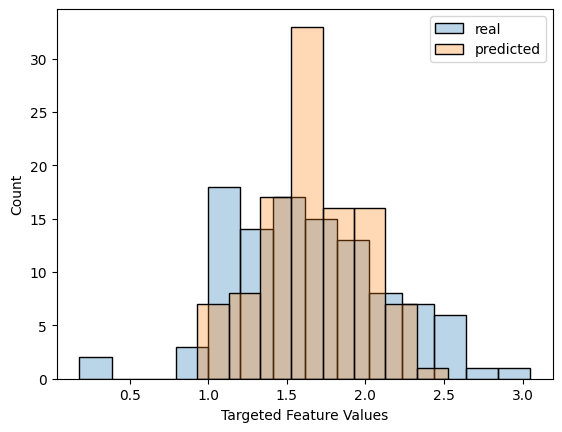

In [12]:
d,axs = pl.subplots()
sns.histplot (results_df.Actual, alpha=0.3, label = 'real', ax = axs, binwidth=0.2)
sns.histplot (results_df.CatBoost_Pred, alpha=0.3, label = 'predicted', ax=axs, binwidth=0.2)
axs.legend ()
axs.set_xlabel ("Targeted Feature Values")

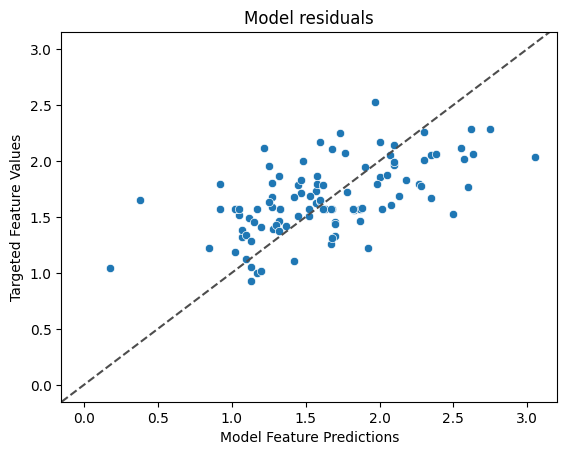

In [13]:
#plot residuals and check for linearity
f, ax = pl.subplots()
sns.scatterplot (y = results_df.CatBoost_Pred, x = results_df.Actual, ax = ax)
pl.title ("Model residuals")
pl.ylabel ("Targeted Feature Values")
pl.xlabel ("Model Feature Predictions")
pl.axline ([0,0], [3,3], ls="--", c=".3")

Text(0.5, 0, 'Residuals')

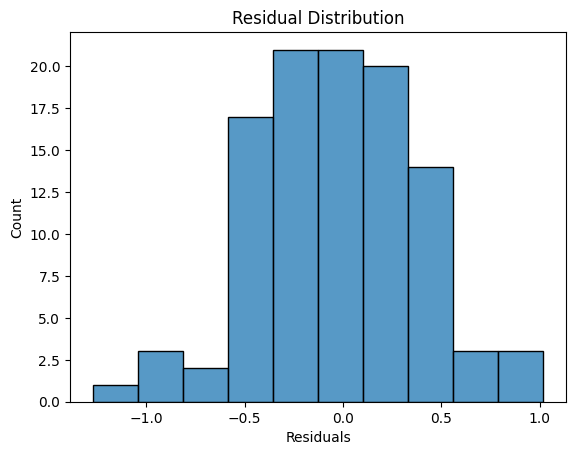

In [14]:
#visualise histogram of residuals
residuals = results_df.Actual-results_df.CatBoost_Pred
sns.histplot (residuals)
pl.title ("Residual Distribution")
pl.xlabel ("Residuals")

# Feature importance analysis

In [15]:
# Combine permutation importance results across folds
all_importance = pd.concat(perm_importance_results)
pfi_mean_importance = all_importance.groupby('feature', as_index=False).agg({
    'PFI_values_mean': 'mean',
    'Importance_Std': 'mean'
}).sort_values('PFI_values_mean', ascending=False)

print("\nMean Permutation Importance across folds:")
print(pfi_mean_importance)


Mean Permutation Importance across folds:
                             feature  PFI_values_mean  Importance_Std
4                     driverTraining         0.252162        0.128932
7                        eventNumber         0.157644        0.075210
0                                AVR         0.155610        0.106511
13             totalGlanceTimeOnRoad         0.077584        0.062745
16                 yawGazeDispersion         0.058332        0.051359
5                  drivingExperience         0.024995        0.054177
9                pitchGazeDispersion         0.023879        0.033088
1                                Age         0.023457        0.029997
12            totalGlanceTimeOffRoad         0.010010        0.025506
6            euclideanGazeDispersion         0.008253        0.023643
2                             Gender         0.007166        0.021822
3                             attenD         0.002866        0.004521
15         totalGlanceTimeRearMirror         0.

<ErrorbarContainer object of 3 artists>

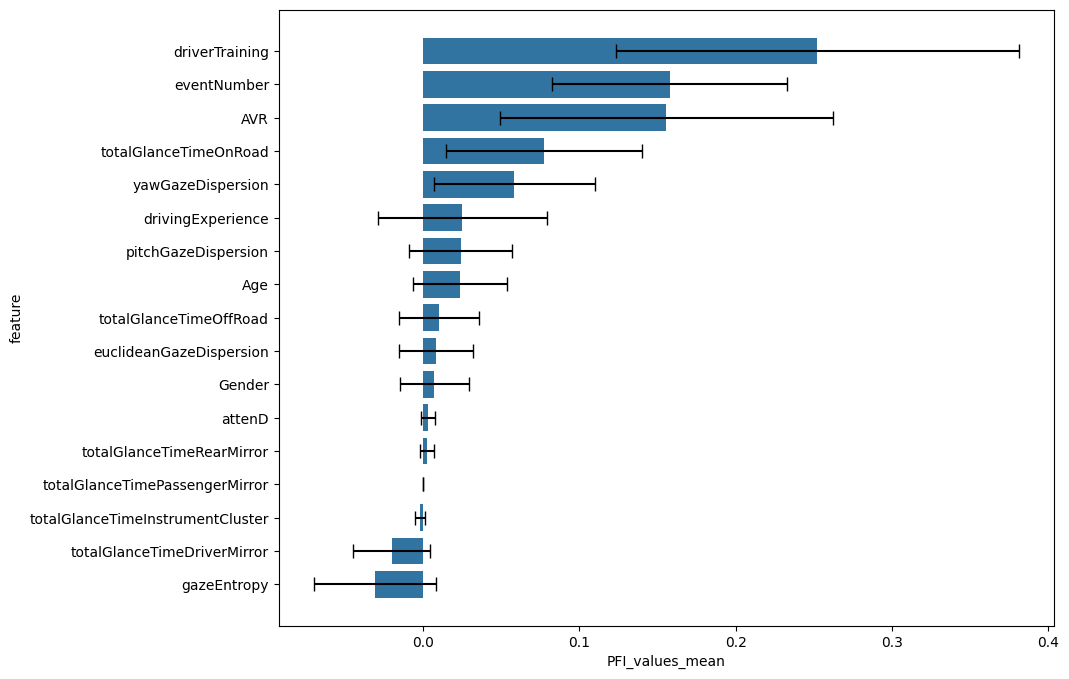

In [16]:
plt.figure(figsize=(10, 8))
sns.barplot(
    x='PFI_values_mean',
    y=pfi_mean_importance.feature,
    data=pfi_mean_importance,
)

# Add error bars manually
plt.errorbar(
    x=pfi_mean_importance['PFI_values_mean'],
    y=range(len(pfi_mean_importance.index)),
    xerr=pfi_mean_importance['Importance_Std'],
    fmt='none',  # Don't add any markers
    color='black',
    capsize=5
)
    

In [17]:
# Average SHAP values across folds
all_shap_values = np.concatenate(shap_values_per_fold)
shap_df = pd.DataFrame(all_shap_values, columns=feature_cols)

# Calculate mean absolute SHAP values for feature importance
mean_abs_shap = np.abs(shap_df).mean()
shap_mean_feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap_value': mean_abs_shap.values
}).sort_values('mean_abs_shap_value', ascending=False)

In [18]:
shap_mean_feature_importance

,feature,mean_abs_shap_value
1,driverTraining,0.181229
2,eventNumber,0.088757
5,AVR,0.080034
4,drivingExperience,0.064361
14,totalGlanceTimeOnRoad,0.060400
9,yawGazeDispersion,0.058042
8,gazeEntropy,0.045365
3,Age,0.041932
10,pitchGazeDispersion,0.036828
0,Gender,0.035100


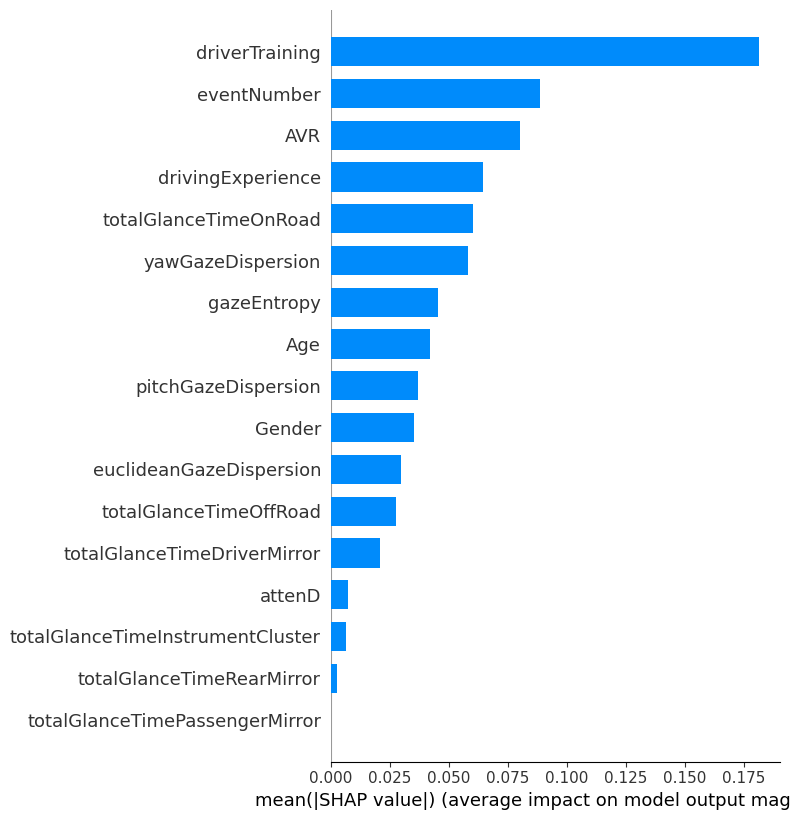

In [19]:
shap.summary_plot(all_shap_values, df[feature_cols], plot_type="bar")

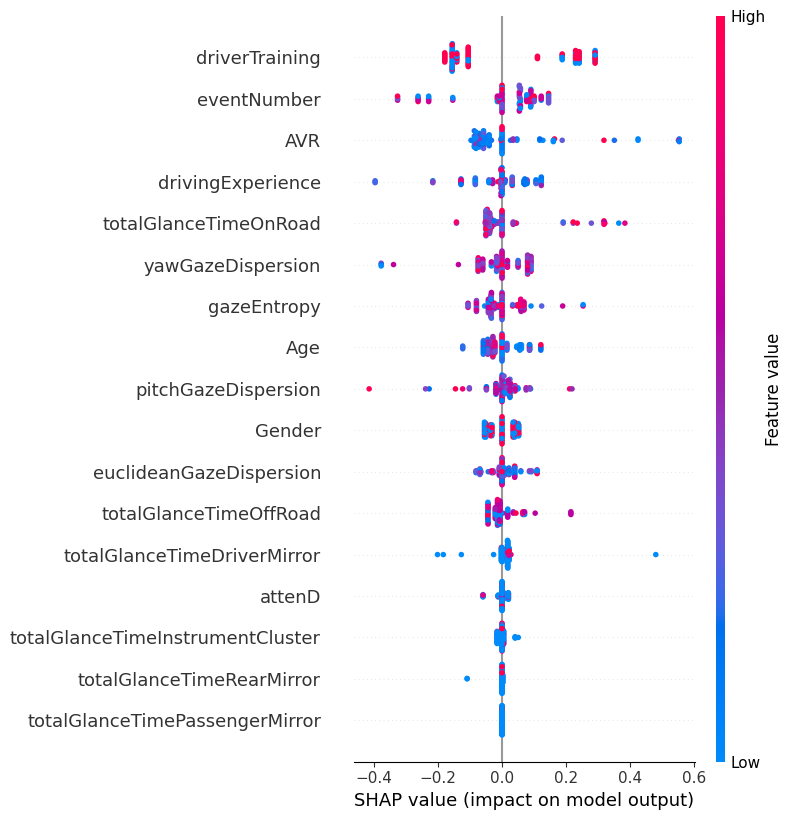

In [20]:
shap.summary_plot(all_shap_values, df[feature_cols])

In [21]:
def combine_shap_pfi_rankings(shap_importance_df, pfi_importance_df):
    """
    Combine SHAP and PFI rankings using rank averaging.
    """

    # Create rank columns (1 = most important)
    shap_df = shap_importance_df.copy()
    shap_df['shap_rank'] = shap_df['mean_abs_shap_value'].rank(ascending=False, method='min')

    pfi_df = pfi_importance_df.copy()
    pfi_df['pfi_rank'] = pfi_df['PFI_values_mean'].rank(ascending=False, method='min')

    # Merge on feature names
    combined = pd.merge(
        shap_df[['feature', 'shap_rank', 'mean_abs_shap_value']],
        pfi_df[['feature', 'pfi_rank', 'PFI_values_mean']],
        left_on='feature', right_on='feature'
    )

    # Average the ranks
    combined['average_rank'] = (combined['shap_rank'] + combined['pfi_rank']) / 2

    # Sort by average rank (lower = better)
    combined = combined.sort_values('average_rank')

    # Create a final importance score for compatibility with stepwise function
    # (just invert the rank so higher = more important)
    combined['combined_importance'] = len(combined) - combined['average_rank'] + 1

    # Clean up the output
    result = combined[['feature', 'average_rank', 'combined_importance',
                      'shap_rank', 'pfi_rank', 'mean_abs_shap_value', 'PFI_values_mean']]

    return result


def print_ranking_comparison(combined_df, top_n=15):
    print("=== FEATURE RANKING COMPARISON ===\n")
    print(f"{'Rank':<4} {'Feature':<25} {'SHAP':<6} {'PFI':<6} {'Avg':<6}")
    print("-" * 55)

    for i, row in combined_df.head(top_n).iterrows():
        print(f"{int(row.name + 1):<4} {row['feature']:<25} "
              f"{int(row['shap_rank']):<6} {int(row['pfi_rank']):<6} "
              f"{row['average_rank']:<6.1f}")

    print(f"\nShowing top {top_n} features by combined ranking")




combined_importance = combine_shap_pfi_rankings(shap_mean_feature_importance,
                                                pfi_mean_importance)
combined_importance


,feature,average_rank,combined_importance,shap_rank,pfi_rank,mean_abs_shap_value,PFI_values_mean
0,driverTraining,1.0,17.0,1.0,1.0,0.181229,0.252162
1,eventNumber,2.0,16.0,2.0,2.0,0.088757,0.157644
2,AVR,3.0,15.0,3.0,3.0,0.080034,0.155610
4,totalGlanceTimeOnRoad,4.5,13.5,5.0,4.0,0.060400,0.077584
3,drivingExperience,5.0,13.0,4.0,6.0,0.064361,0.024995
5,yawGazeDispersion,5.5,12.5,6.0,5.0,0.058042,0.058332
7,Age,8.0,10.0,8.0,8.0,0.041932,0.023457
8,pitchGazeDispersion,8.0,10.0,9.0,7.0,0.036828,0.023879
9,Gender,10.5,7.5,10.0,11.0,0.035100,0.007166
10,euclideanGazeDispersion,10.5,7.5,11.0,10.0,0.029819,0.008253


In [22]:
results_df = results_df.rename(columns={'CatBoost_Pred': 'Pred'})
file = open ('PDRA_CatBoost.pickle', 'wb')
pickle.dump (best_cat, file)
file.close
shap_df.to_pickle ('SHAP_Values_CatBoost.pkl')
results_df.to_pickle ('SHAP_Predictions_CatBoost.pkl')
combined_importance.to_pickle ('combined_importance_CatBoost.pkl')